# MSA 2026 Phase 2 - Part 1

In [50]:
# Install necessary libraries
# !pip install -r requirements.txt

In [51]:
# Import necessary libraries
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Find all variables and understand them

In [52]:
# Load X store sales data & preview the first 5 rows
xsales_data = pd.read_csv('datasets/X store sales/store_sales.csv', encoding='latin1')
xsales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


### 1.1 Check data and correct schema where necessary

In [53]:
# Check data types and missing values of the dataset
xsales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   str    
 2   Order Date     2121 non-null   str    
 3   Ship Date      2121 non-null   str    
 4   Ship Mode      2121 non-null   str    
 5   Customer ID    2121 non-null   str    
 6   Customer Name  2121 non-null   str    
 7   Segment        2121 non-null   str    
 8   Country        2121 non-null   str    
 9   City           2121 non-null   str    
 10  State          2121 non-null   str    
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   str    
 13  Product ID     2121 non-null   str    
 14  Category       2121 non-null   str    
 15  Sub-Category   2121 non-null   str    
 16  Product Name   2121 non-null   str    
 17  Sales          2121 non-null   float64
 18  Quantity       2121

In [73]:
# Double check if there is null values in the dataset
xsales_data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Quarter          0
dtype: int64

In [54]:
# Check duplicates
duplicates = xsales_data.duplicated().sum()
print(f'The number of duplicate records is: {duplicates}')

The number of duplicate records is: 0


* **Summary**: The dataset contains 2,121 records and 21 variables; No missing values and no duplicates are found.

In [79]:
# Make sure all identifier variables are converted to strings
# Identifier variables: Row ID, Order ID, Customer ID, Postal Code, Product ID;
# Date variables: Order Date, Ship Date;
# Categorical variables: Ship Mode,Customer Name, Segment, Country, City, State, Region, 
# Category, Sub-Category, Product Name;
# Numerical variables: Sales, Quantity, Discount, Profit

id_columns = [
    'Row ID',
    'Postal Code'
]
xsales_data[id_columns] = xsales_data[id_columns].astype(str)

# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']
xsales_data[date_columns] = xsales_data[date_columns].apply(pd.to_datetime)

### 1.2 View time range of the data

In [74]:
print('Data covers from {} to {}'.format(xsales_data['Order Date'].min(), xsales_data['Order Date'].max()))

Data covers from 2014-01-06 00:00:00 to 2017-12-30 00:00:00


### 1.3 Statistical measures of key numeric columns

In [56]:
# Get key statistical measures of the numeric columns:sales/quantity/discount/profit
xsales_data[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000
mean,349.834887,3.785007,0.173923,8.699327
std,503.179145,2.251620,0.181547,136.049246
min,1.892000,1.000000,0.000000,-1862.312400
25%,47.040000,2.000000,0.000000,-12.849000
50%,182.220000,3.000000,0.200000,7.774800
75%,435.168000,5.000000,0.300000,33.726600
max,4416.174000,14.000000,0.700000,1013.127000


* **Observation**: There are definitely outliers in the numerical columns refering to the means and medians

### 1.4 Visualisation to check data distribution

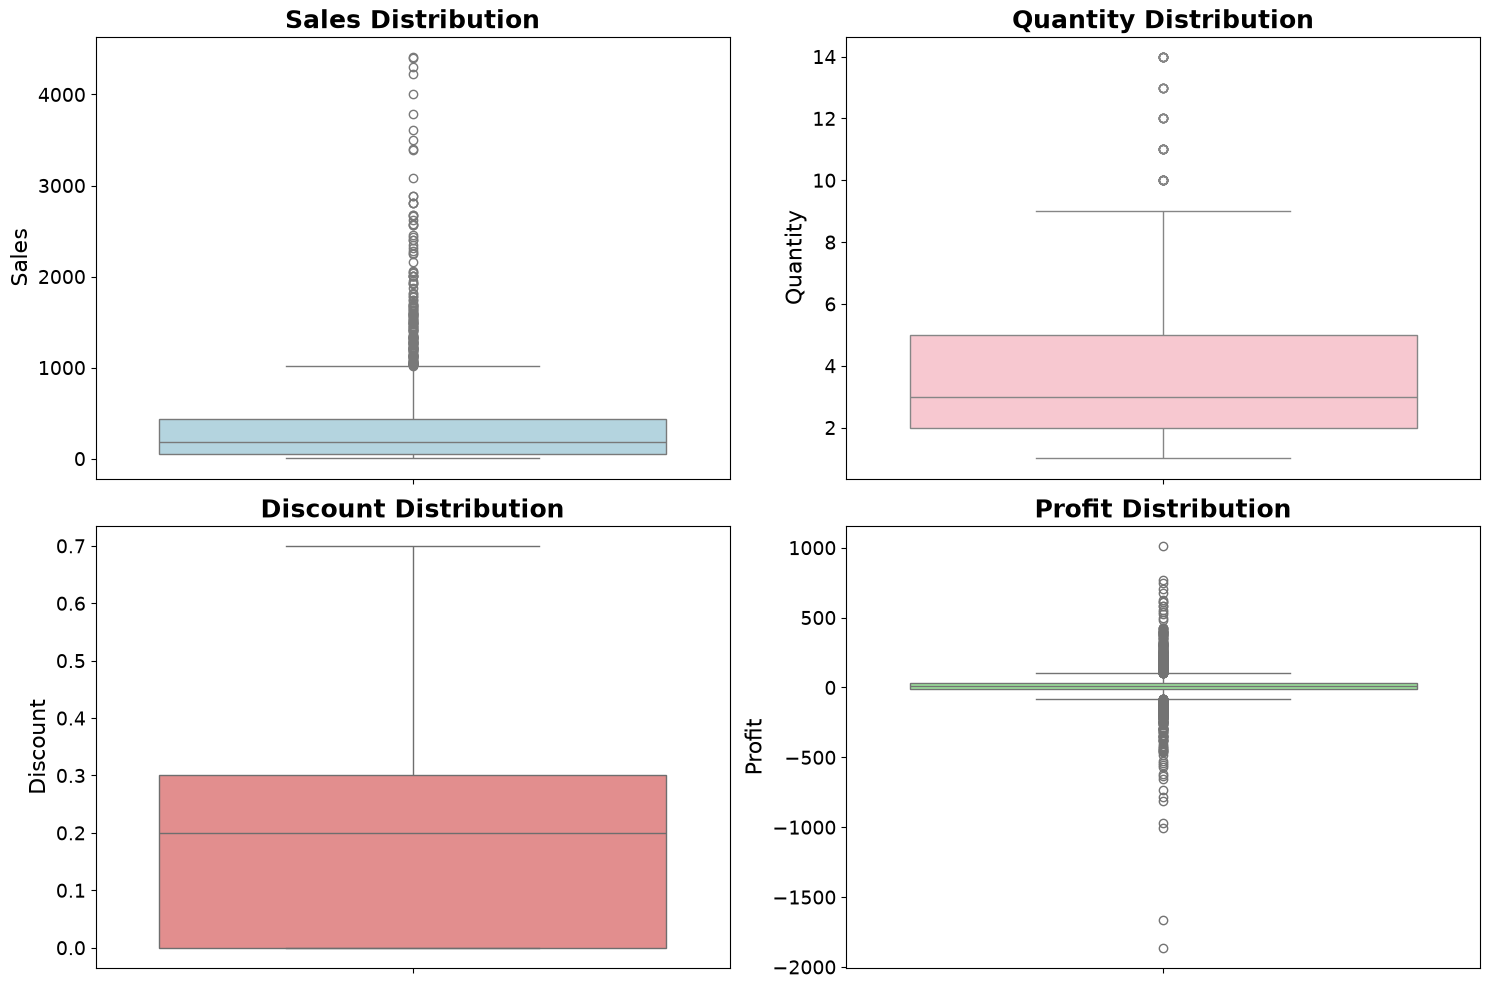

In [75]:
# Check distribution of sales, quantity, discount and profit using boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=xsales_data['Sales'], ax=axes[0, 0], color='lightblue')
sns.boxplot(data=xsales_data['Quantity'], ax=axes[0, 1], color='pink')
sns.boxplot(data=xsales_data['Discount'], ax=axes[1, 0], color='lightcoral')
sns.boxplot(data=xsales_data['Profit'], ax=axes[1, 1], color='lightgreen')

# Set title and label format for all subplots
# Titles for each subplot
titles = [
    "Sales Distribution",
    "Quantity Distribution",
    "Discount Distribution",
    "Profit Distribution"
]

# Style settings
title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'black'
}

# set all x and y labels with font size 16; set all ticks with font size 14
label_size = 16
tick_size = 14

# Apply to all subplots
for ax, title in zip(axes.flat, titles):

    # Title
    ax.set_title(title, **title_style)

    # Axis labels
    ax.set_xlabel(ax.get_xlabel(), fontsize=label_size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=label_size)

    # Tick labels
    ax.tick_params(axis='both', labelsize=tick_size)


plt.tight_layout()
plt.show()


In [58]:
# Examine outliers in sales using quantiles
sales_q1 = xsales_data['Sales'].quantile(0.25)
sales_q3 = xsales_data['Sales'].quantile(0.75)
sales_iqr = sales_q3 - sales_q1
sales_lower_bound = sales_q1 - 1.5 * sales_iqr
sales_upper_bound = sales_q3 + 1.5 * sales_iqr
outliers_sales = xsales_data[(xsales_data['Sales'] < sales_lower_bound) | (xsales_data['Sales'] > sales_upper_bound)]
print(f'Number of outliers in Sales: {outliers_sales.shape[0]}')

# Show outlier records in decending order of sales amount
outliers_sales_sorted = outliers_sales.sort_values(by='Sales', ascending=False)
outliers_sales_sorted.head()

Number of outliers in Sales: 164


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1517,7244,CA-2017-118892,2017-08-17,2017-08-22,Second Class,TP-21415,Tom Prescott,Consumer,United States,Philadelphia,...,19134,East,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,4416.174,9,0.3,-630.8820
2063,9742,CA-2015-117086,2015-11-08,2015-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,5408,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.900,5,0.0,1013.1270
2044,9640,CA-2015-116638,2015-01-28,2015-01-31,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,28027,South,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1232,5918,US-2015-126977,2015-09-17,2015-09-23,Standard Class,PF-19120,Peter Fuller,Consumer,United States,New York City,...,10035,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4228.704,6,0.2,158.5764
1365,6536,CA-2014-128209,2014-11-17,2014-11-22,Standard Class,GT-14710,Greg Tran,Consumer,United States,Buffalo,...,14215,East,FUR-BO-10002213,Furniture,Bookcases,DMI Eclipse Executive Suite Bookcases,4007.840,10,0.2,-50.0980


In [59]:
# Examine outliers in profit using quantiles
profit_q1 = xsales_data['Profit'].quantile(0.25)
profit_q3 = xsales_data['Profit'].quantile(0.75)
profit_iqr = profit_q3 - profit_q1
profit_lower_bound = profit_q1 - 1.5 * profit_iqr
profit_upper_bound = profit_q3 + 1.5 * profit_iqr
outliers_profit = xsales_data[(xsales_data['Profit'] < profit_lower_bound) | (xsales_data['Profit'] > profit_upper_bound)]
print(f'Number of outliers in Profit: {outliers_profit.shape[0]}')

# Show outlier records in decending order of profit amount
outliers_profit_sorted = outliers_profit.sort_values(by='Profit', ascending=False)
outliers_profit_sorted.head()

Number of outliers in Profit: 407


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2063,9742,CA-2015-117086,2015-11-08,2015-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,5408,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.90,5,0.0,1013.1270
1452,6885,CA-2015-120677,2015-05-31,2015-06-04,Standard Class,BD-11320,Bill Donatelli,Consumer,United States,Minneapolis,...,55407,Central,FUR-CH-10002320,Furniture,Chairs,Hon Pagoda Stacking Chairs,2567.84,8,0.0,770.3520
1577,7475,CA-2014-167199,2014-01-06,2014-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.82,9,0.0,746.4078
1070,5171,CA-2016-122903,2016-05-27,2016-05-29,Second Class,LA-16780,Laura Armstrong,Corporate,United States,Detroit,...,48205,Central,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,3504.90,5,0.0,700.9800
366,1792,CA-2014-120474,2014-12-01,2014-12-03,First Class,RP-19390,Resi Plking,Consumer,United States,Madison,...,53711,Central,FUR-CH-10001854,Furniture,Chairs,Office Star - Professional Matrix Back Chair w...,2807.84,8,0.0,673.8816


* **Observations:** Combining the boxplots with the outlier records, it can be observed that Sales and Quantity are right skewed with several high-value data points, while Profit contains both positive and negative extreme values. These observations are considered to be consistent with real-world retail transactions rather than data quality issues.

* **Decision:**
1) Keep outliers as these could reflect real-world business cases;
2) Standardise numerical variables to reduce differences in feature scales for downstream machine learning tasks.

## 2. Clean data

### 2.1 Standardise data

In [80]:
# Standardise the numeric columns to deal with outliers and different scales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xsales_data_scaled = xsales_data.copy()
xsales_data_scaled[['Sales', 'Quantity', 'Discount', 'Profit']] = scaler.fit_transform(xsales_data_scaled[['Sales', 'Quantity', 'Discount', 'Profit']])
xsales_data_scaled.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192,2016,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412,2016,4
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006,2015,4
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216,2014,2
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237,2014,2


### 2.2 Check categorical balance

#### 2.2.1 By Year

In [81]:
# Check sample balance by year
# extract year from order date and create a new column for it
xsales_data_scaled['Year'] = xsales_data_scaled['Order Date'].dt.year
# group by year and get the count of samples for each year
yearly_counts = xsales_data_scaled.groupby('Year').size()
yearly_counts

Year
2014    421
2015    452
2016    562
2017    686
dtype: int64

#### 2.2.2 By product Sub-Category

In [82]:
# Check sample balance by Sub-Category
subcategory_counts = xsales_data_scaled['Sub-Category'].value_counts()
subcategory_counts

Sub-Category
Furnishings    957
Chairs         617
Tables         319
Bookcases      228
Name: count, dtype: int64

#### 2.2.3 By order Region

In [83]:
# Check sample balance by Region
region_counts = xsales_data_scaled['Region'].value_counts()
region_counts

Region
West       707
East       601
Central    481
South      332
Name: count, dtype: int64

#### 2.2.4 By Consumer Segment

In [84]:
# Check sample balance by consumer segment
consumer_segment_counts = xsales_data_scaled['Segment'].value_counts()
consumer_segment_counts

Segment
Consumer       1113
Corporate       646
Home Office     362
Name: count, dtype: int64

* **Decision:** Despite that some categories contain more records than others, the imbalance is not considered severe. Therefore, no sampling method needs to be applied.

### 2.3 Feature engineering

In [85]:
# Add month/quarter columns for potential seasonality analysis
xsales_data_scaled['Month'] = xsales_data_scaled['Order Date'].dt.month
xsales_data_scaled['Quarter'] = xsales_data_scaled['Order Date'].dt.quarter
xsales_data_scaled.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Quarter,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192,2016,4,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412,2016,4,11
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006,2015,4,10
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216,2014,2,6
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237,2014,2,6


### 2.4 Feature selection

In [67]:
# Remove identifier columns that do not provide predictive information.
# These columns uniquely identify records and may lead to overfitting
# if included in machine learning models. Postal Code is kept as it may provide 
# some predictive information about the location of the customer.
id_columns = [
    'Row ID',
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID'
]
xsales_data_model = xsales_data_scaled.drop(columns=id_columns)
xsales_data_model.head()

,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter
0,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,Bush Somerset Collection Bookcase,-0.174681,-0.792953,-0.958228,0.244192,2016,11,4
1,2016-11-08,2016-11-11,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",0.759561,-0.348723,-0.958228,1.550412,2016,11,4
2,2015-10-11,2015-10-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1.208090,0.539736,1.521050,-2.880006,2015,10,4
3,2014-06-09,2014-06-14,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,-0.598288,1.428194,-0.958228,0.040216,2014,6,2
4,2014-06-09,2014-06-14,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,Chromcraft Rectangular Conference Tables,2.696195,2.316653,0.143673,0.563237,2014,6,2


## 3. Visualise data

### 3.1 Yearly stats & visualisation on key numeric columns

In [68]:
# Group by year and get statistical measures of sales, quantity, discount and profit for each year
yearly_stats = xsales_data_scaled.groupby('Year')[['Sales', 'Quantity', 'Discount', 'Profit']].describe()
yearly_stats

Sales                                                              \
      count      mean       std       min       25%       50%       75%   
Year                                                                      
2014  421.0  0.046803  1.044235 -0.688495 -0.592165 -0.334681  0.323069   
2015  452.0  0.054502  1.153922 -0.689529 -0.587605 -0.313968  0.127858   
2016  562.0  0.008115  0.948300 -0.690785 -0.601727 -0.325557  0.207086   
2017  686.0 -0.071282  0.897863 -0.691652 -0.612004 -0.354921  0.063827   

               Quantity            ...  Discount           Profit            \
           max    count      mean  ...       75%       max  count      mean   
Year                               ...                                        
2014  7.271501    421.0  0.031140  ...  0.694624  2.898426  421.0  0.031352   
2015  8.060790    452.0  0.063073  ...  0.143673  2.898426  452.0 -0.014914   
2016  6.271741    562.0  0.052032  ...  0.694624  2.898426  562.0  0.027092   
2017  8.083201    686.0 -0.103296  ...  0.143673  2.898426  686.0 -0.031609   

                                                                   
           std        min       25%       50%       75%       max  
Year                                                               
2014  0.887080  -5.464205 -0.168569 -0.007373  0.156775  5.423642  
2015  1.308331 -13.755702 -0.154379  0.010857  0.236447  7.384565  
2016  0.895030  -6.052049 -0.152626 -0.003273  0.187914  5.089656  
2017  0.910193  -7.436436 -0.165067 -0.013430  0.145059  4.418680  

[4 rows x 32 columns]

In [86]:
# Examine yearly-quarterly trend of sales, quantity and profit using bar chart

# Create Year and Quarter columns
xsales_data['Year'] = xsales_data['Order Date'].dt.year
xsales_data['Quarter'] = xsales_data['Order Date'].dt.quarter

# Calculate quarterly average for sales, quantity and profit
quarterly_avg_by_yr = (
    xsales_data
    .groupby(['Year', 'Quarter'])[['Sales', 'Discount', 'Quantity', 'Profit']]
    .mean()
    .reset_index()
)

# Create a Year-Quarter label for plotting
quarterly_avg_by_yr['Year_Quarter'] = (
    quarterly_avg_by_yr['Year'].astype(str) + ' Q' + quarterly_avg_by_yr['Quarter'].astype(str)
)

quarterly_avg_by_yr.head()

,Year,Quarter,Sales,Discount,Quantity,Profit,Year_Quarter
0,2014,1,377.602317,0.185000,3.733333,-3.374947,2014 Q1
1,2014,2,350.796870,0.179000,3.750000,10.010223,2014 Q2
2,2014,3,371.308658,0.159027,3.796460,25.631115,2014 Q3
3,2014,4,384.018370,0.198036,3.988095,11.685051,2014 Q4
4,2015,1,506.927752,0.178889,4.518519,-21.560146,2015 Q1


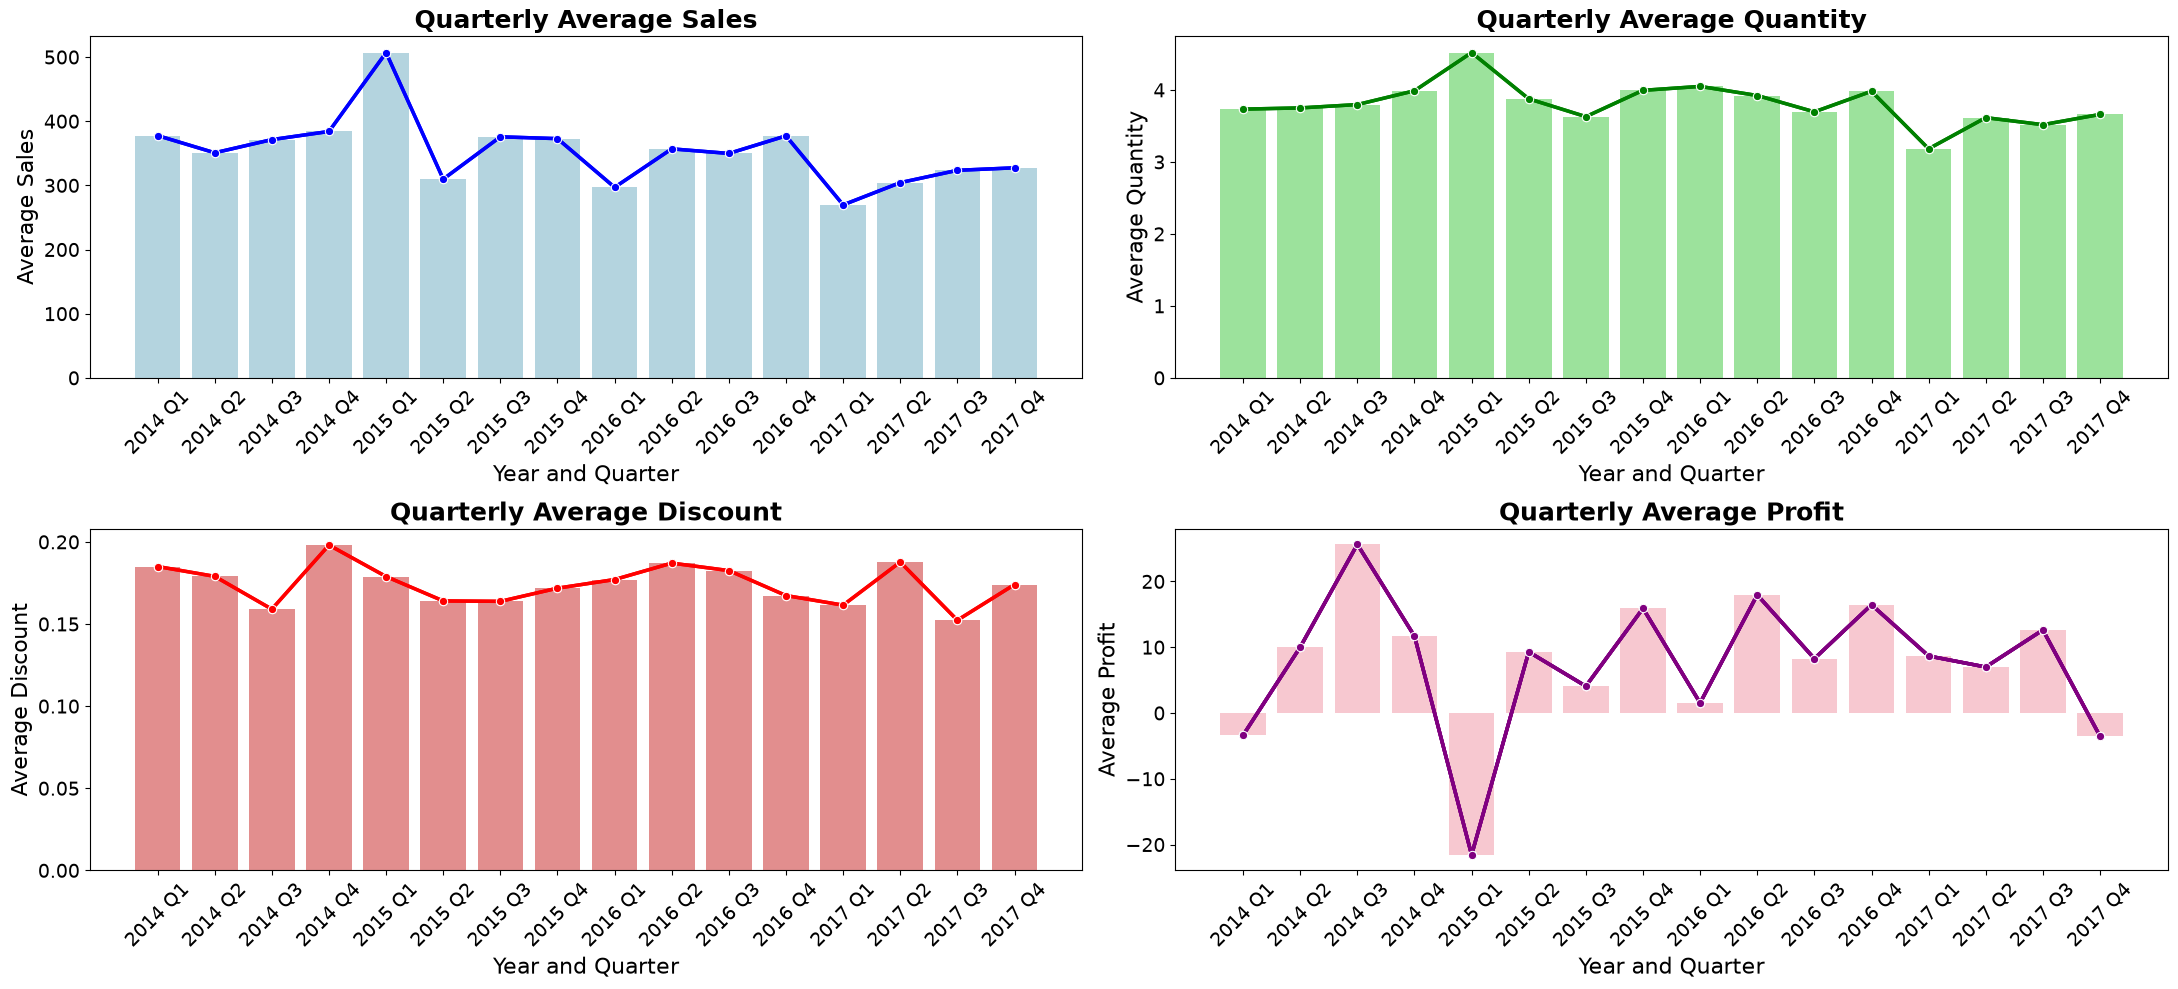

In [90]:
# Visualise with bar charts
fig, axes = plt.subplots(2, 2, figsize=(22, 10))

metrics = ['Sales', 'Quantity', 'Discount', 'Profit']
titles = [
    'Quarterly Average Sales',
    'Quarterly Average Quantity',
    'Quarterly Average Discount',
    'Quarterly Average Profit'
]

title_style = {
    'fontsize': 18,
    'fontweight': 'bold',
    'color': 'black'
}

bar_colors = ['lightblue', 'lightgreen', 'lightcoral', 'pink']
line_colors = ['blue', 'green', 'red', 'purple']

for ax, metric, title, color, line_color in zip(
    axes,
    metrics,
    titles,
    bar_colors,
    line_colors
):

    for ax, metric, title, color, line_color in zip(
        axes.flatten(),
        metrics,
        titles,
        bar_colors,
        line_colors
    ):
        sns.barplot(
            data=quarterly_avg_by_yr,
            x='Year_Quarter',
            y=metric,
            color=color,
            ax=ax
        )

        sns.lineplot(
            data=quarterly_avg_by_yr,
            x='Year_Quarter',
            y=metric,
            color=line_color,
            marker='o',
            linewidth=2.5,
            ax=ax
        )

        ax.set_title(title, **title_style)
        ax.set_xlabel('Year and Quarter', fontsize=16)
        ax.set_ylabel(f'Average {metric}', fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.tick_params(axis='x', rotation=45)

    sns.lineplot(
        data=quarterly_avg_by_yr,
        x='Year_Quarter',
        y=metric,
        color=line_color,
        marker='o',
        linewidth=2.5,
        ax=ax
    )

    ax.set_title(title, **title_style)
    ax.set_xlabel('Year and Quarter', fontsize=16)
    ax.set_ylabel(f'Average {metric}', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* **Discussion:** To further explore potential seasonality, quarterly averages of Sales, Quantity, Discount and Profit were visualised. Sales and Profit fluctuated across quarters, but no clear recurring seasonal pattern was evident over the four-year period. In contrast, Quantity and Discount remained relatively stable, suggesting that purchasing behaviour and discount strategies were fairly consistent over time.

## 4. Identify correlated variables

In [91]:
# Identify correlated features in xsales_data_model dataset using a correlation matrix
# Drop non-numeric columns for correlation analysis
numeric_columns = xsales_data_model.select_dtypes(include=[np.number]).columns
xsales_data_model_numeric = xsales_data_model[numeric_columns]
correlation_matrix = xsales_data_model_numeric.corr()
correlation_matrix

,Postal Code,Sales,Quantity,Discount,Profit,Year,Month,Quarter
Postal Code,1.000000,-0.011786,0.013700,0.106736,-0.026335,-0.016405,0.002659,0.006537
Sales,-0.011786,1.000000,0.437464,-0.028576,0.173510,-0.047660,0.029083,0.018845
Quantity,0.013700,0.437464,1.000000,-0.015695,0.061213,-0.052997,0.011099,0.014225
Discount,0.106736,-0.028576,-0.015695,1.000000,-0.483769,-0.017077,-0.003088,-0.002410
Profit,-0.026335,0.173510,0.061213,-0.483769,1.000000,-0.017445,0.029176,0.016240
Year,-0.016405,-0.047660,-0.052997,-0.017077,-0.017445,1.000000,-0.009377,-0.004719
Month,0.002659,0.029083,0.011099,-0.003088,0.029176,-0.009377,1.000000,0.969000
Quarter,0.006537,0.018845,0.014225,-0.002410,0.016240,-0.004719,0.969000,1.000000


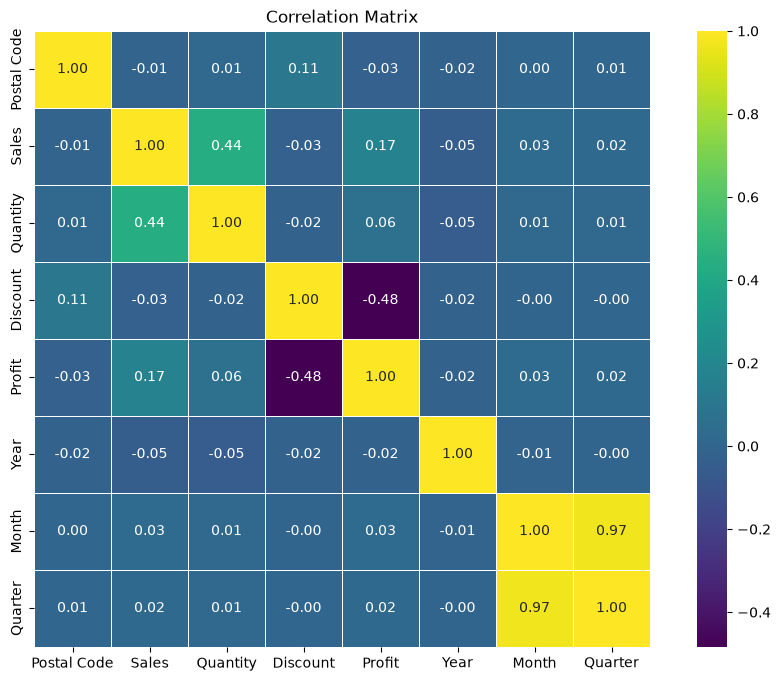

In [94]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

* Most variables showed weak correlations, indicating limited multicollinearity. The only strong correlation was between **Month** and **Quarter** (0.97), which is expected as Quarter is derived from Month, while **Discount** and **Profit** exhibited a moderate negative relationship (-0.48).

## 5. Summary

This notebook applies exploratory data analysis (EDA) and preprocessing to prepare the **X Store Sales dataset** for future machine learning tasks. I first explored the dataset by **checking the variables, data types and the time range** covered by the data. I also checked for missing values and duplicate records, and found that the dataset was complete with **no missing values or duplicates.**

To better understand the numerical features, I examined **summary statistics and visualised the distributions** of Sales, Quantity, Discount and Profit using boxplots. Although Sales and Profit contained a number of outliers, I **decided to keep** them because they are likely to represent genuine business transactions rather than data quality issues. I then standardised the numerical variables so they are on a similar scale for future modelling.

I also explored the balance of several categorical variables, including Year, Region, Segment and Sub-Category. While some categories had more observations than others, the differences were **not large enough to justify resampling.** As part of feature engineering, I extracted Month and Quarter from the order date and created **additional visualisations** to examine quarterly trends in Sales, Quantity and Profit, which helped reveal **potential seasonal patterns in the data.**

Finally, I **removed identifier columns** such as Order ID and Customer ID because they are unlikely to provide useful predictive information. A correlation analysis showed that **Sales and Quantity** are moderately positively correlated, while **Discount** has a moderate negative relationship with **Profit**. I also found that **Month and Quarter** are highly correlated, suggesting that one of them could be removed depending on the target of downstream modelling.
